Demostrar las capacidades de GEE para extraer datos de una cuenca en especial y mapear su DEM

In [ ]:
#Paso 1 Importar librerías
import ee #el api de GEE
import geemap # el visor de GEE


In [ ]:
#paso 2 Autenticarse de GEE -  Debe seleccionar un proyecto GEE
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='ee-cydata') # <- cambiar a su proyecto de GEE debe estar registrado en GEE

print("Entorno de Google Earth Engine configurado y autenticado correctamente.")


Entorno de Google Earth Engine configurado y autenticado correctamente.


In [ ]:
# --- VARIABLES DE CONTROL (Estudio de Caso Personalizado) ---
# Nombre estándar de la base de datos FAO GAUL
PAIS_NOMBRE = 'Costa Rica'

# ID único de la cuenca (HYBAS_ID) proveniente de HydroBASINS Nivel 7/12
CUENCA_ID = 7121221580
# -----------------------------------------------------------
##TODO inspeccionar la fuente de datos geolibre ?

print(f"Parámetros establecidos: País - {PAIS_NOMBRE}, ID de Cuenca - {CUENCA_ID}")


Parámetros establecidos: País - Costa Rica, ID de Cuenca - 7121221580


In [ ]:
#cargar los datos de la nube (cuencas) desde GEE - NUBE
paises = ee.FeatureCollection("FAO/GAUL/2015/level0")
cuencas_global = ee.FeatureCollection("WWF/HydroSHEDS/v1/Basins/hybas_12") ##vector
dem_global = ee.Image("USGS/SRTMGL1_003") ##raster

print("Datasets globales cargados exitosamente.")

Datasets globales cargados exitosamente.


In [ ]:
# 1. Filtrado de la región administrativa por nombre de país
pais_subset = paises.filter(ee.Filter.eq('ADM0_NAME', PAIS_NOMBRE))

# 2. Selección de la cuenca de estudio mediante su identificador único
cuenca_estudio = cuencas_global.filter(ee.Filter.eq('HYBAS_ID', CUENCA_ID))

# 3. Operación de Recorte (Clipping)
# El DEM se enmascara espacialmente usando la geometría del vector de la cuenca.
dem_recortado = dem_global.clip(cuenca_estudio)

# 4. Verificación de entidades (Uso discreto de .getInfo() para depuración)
try:
    count = cuenca_estudio.size().getInfo()
    print(f"Procesamiento completado: {count} entidad(es) encontrada(s) para el ID {CUENCA_ID}.")
except Exception as e:
    print("Error al recuperar información del servidor.")

Procesamiento completado: 1 entidad(es) encontrada(s) para el ID 7121221580.


<Axes: >

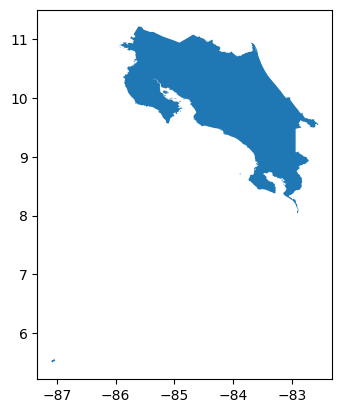

In [ ]:
# para ver el pais y ver que efectivamente seleccionamos usamos geopandas
import geopandas as gpd
pais_subset_gdf = gpd.GeoDataFrame.from_features(pais_subset.getInfo()['features'])
pais_subset_gdf.plot()



In [ ]:
#visualizar DEM_01.tif
import matplotlib.pyplot as plt
import rasterio
##abrir DEM_01.tif y visualizar
#TODO


In [ ]:
#utilizamos geemap para ver los objetos de GEE seleccionados (la cuenca) y recortados (DEM recortado de la cuenca)
Map = geemap.Map()


# Parámetros de visualización para el relieve
# Paleta: '0000ff' (Azul - zonas bajas), '00ffff' (Cian), 'ffff00' (Amarillo),
# 'ff0000' (Rojo), 'ffffff' (Blanco - picos elevados)
vis_params_dem = {
    'min': 0,
    'max': 3500,
    'palette': ['0000ff', '00ffff', 'ffff00', 'ff0000', 'ffffff']
}

# Centrar la visualización en la cuenca con un nivel de zoom adecuado (10)
Map.centerObject(cuenca_estudio, 10)

# Inserción de capas en el mapa
Map.addLayer(dem_recortado, vis_params_dem, 'DEM Recortado (Elevación)')
Map.addLayer(cuenca_estudio, {'color': '000000', 'width': 2}, 'Límite Vectorial de la Cuenca')




In [ ]:
Map

Map(center=[9.66568908052654, -83.61249797649613], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
## estadisticas y análisis del DEM
# 1. Estadísticas Descriptivas de Elevación
# Calcular la media, mínima, máxima y desviación estándar de la elevación dentro de la cuenca.
elevacion_stats = dem_recortado.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), None, True).combine(ee.Reducer.stdDev(), None, True),
    geometry=cuenca_estudio.geometry(),
    scale=30, # La resolución del SRTM es 30 metros
    maxPixels=1e9
)

print(f"Estadísticas de Elevación para la Cuenca (metros):")
print(f"  Mínima: {elevacion_stats.get('elevation_min').getInfo():.2f}")
print(f"  Máxima: {elevacion_stats.get('elevation_max').getInfo():.2f}")
print(f"  Media: {elevacion_stats.get('elevation_mean').getInfo():.2f}")
print(f"  Desviación Estándar: {elevacion_stats.get('elevation_stdDev').getInfo():.2f}")

# 2. Cálculo de Pendiente (Slope) y Orientación (Aspect)
# Usamos ee.Terrain.products para calcular pendiente y orientación.
terrain = ee.Terrain.products(dem_recortado)
slope = terrain.select('slope')
aspect = terrain.select('aspect')


print("\nAnálisis de Pendiente, Orientación calculados exitosamente.")

Estadísticas de Elevación para la Cuenca (metros):
  Mínima: 1210.00
  Máxima: 3195.00
  Media: 2105.18
  Desviación Estándar: 456.81

Análisis de Pendiente, Orientación calculados exitosamente.


In [ ]:
##mapa para ver la pendiente sin tocar el mapa original
Map2 = geemap.Map()
vis_params_slope = {
    'min': 0,
    'max': 60,
    'palette': ['white', 'red']
}

Map2.addLayer(slope, vis_params_slope, 'Pendiente)')
##Map.addLayer(cuenca_estudio, {'color': '000000', 'width': 2}, 'Límite Vectorial de la Cuenca')


In [ ]:
Map2

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:

Map.addLayer(dem_global, vis_params_dem, 'DEM Global (Elevación)')

In [ ]:
## como se haría en GEE javascript
# Export.image.toDrive({
#   image: dem_recortado,
#   description: 'DEM_Recortado_Cuenca',
#   scale: 30, // Resolución espacial del SRTM (30 metros)
#   region: cuenca_estudio,
#   fileFormat: 'GeoTIFF',
#   maxPixels: 1e9 // Evita errores si la cuenca es muy grande
# });

In [ ]:
# 5. Configurar la tarea de exportación a Google Drive
print("Configurando la tarea de exportación...")
tarea = ee.batch.Export.image.toDrive(
    image=dem_recortado,
    description='DEM_Recortado_Cuenca_10',
    folder='GEE_Exports',         # Carpeta que se creará en tu Google Drive
    scale=10,                     # Resolución espacial del SRTM (30 metros)
    region=cuenca_estudio.geometry(),      # Geometría pura corregida
    fileFormat='GeoTIFF',
    maxPixels=1e9                 # Límite alto para evitar errores por tamaño
)

# 6. Iniciar el proceso en los servidores de Google
tarea.start()
print("¡Exportación iniciada en los servidores de Google!")
print(f"ID de la tarea: {tarea.id}")
print("Monitoreando el progreso...")

Configurando la tarea de exportación...
¡Exportación iniciada en los servidores de Google!
ID de la tarea: A4JMQRS2PPY5WEJPJIBY62YW
Monitoreando el progreso...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
